Importer les bibliothèques nécessaires

---



In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

Charger les données : dataset Fashion-MNIST



In [2]:
from tensorflow.keras.datasets import fashion_mnist # Changed dataset
from tensorflow.keras.utils import to_categorical

# Charge les données Fashion-MNIST
(X_train_data, Y_train_data), (X_test_data, Y_test_data) = fashion_mnist.load_data() # Changed dataset

N = X_train_data.shape[0]
print(X_train_data[0].shape)

# vecteur image
X_train = np.reshape(X_train_data, (N, 784))
X_test = np.reshape(X_test_data, (X_test_data.shape[0], 784))

X_train = X_train / 255
X_test = X_test / 255

Y_train = to_categorical(Y_train_data, num_classes=10)
Y_test = to_categorical(Y_test_data, num_classes=10)

print(Y_train[0])
print(Y_train_data[0])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(28, 28)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
9


Définir le réseau de neurones

In [3]:
p = 8
modele = Sequential()

# Première couche
modele.add(Dense(p, input_dim=784, activation='sigmoid'))
# Deuxième couche
modele.add(Dense(p, activation='sigmoid'))
# Couche de sortie (10 classes pour Fashion-MNIST)
modele.add(Dense(10, activation='softmax'))

modele.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

print(modele.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │         6,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,442 (25.16 KB)

 Trainable params: 6,442 (25.16 KB)

 Non-trainable params: 0 (0.00 B)

None


Entraîner le modèle

In [4]:
modele.fit(X_train, Y_train, batch_size=32, epochs=40)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1845 - loss: 2.2627
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3983 - loss: 2.0135
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4556 - loss: 1.6799
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5379 - loss: 1.4492
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5609 - loss: 1.2990
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5760 - loss: 1.1935
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5863 - loss: 1.1136
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6098 - loss: 1.0459
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6269 - loss: 0.9952
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6445 - loss: 0.9538
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6574 - loss: 0.9157
Epoch 12/40
1875/1875 ━━━━━━━━

Tester le modèle et afficher les résultats

In [10]:
# A. Évaluation Globale
resultat = modele.evaluate(X_test, Y_test, verbose=0)
print('Valeur de l''erreur sur les données de test (loss):', resultat[0])
print('Précision sur les données de test (accuracy):', resultat[1])

Valeur de lerreur sur les données de test (loss): 0.5341217517852783
Précision sur les données de test (accuracy): 0.8180000185966492


Valeur de lerreur sur les données de test (loss): 0.5341217517852783
Précision sur les données de test (accuracy): 0.8180000185966492
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Sortie réseau (vecteur de probabilités) : [1.9310722e-03 5.4334127e-03 3.8824075e-01 1.8595256e-03 4.9188930e-01
 2.5885566e-03 1.0699884e-01 3.9605948e-07 1.0441209e-03 1.4086333e-05]
Classe attendue : 4
Classe prédite : 4 avec une probabilité de 49.19%


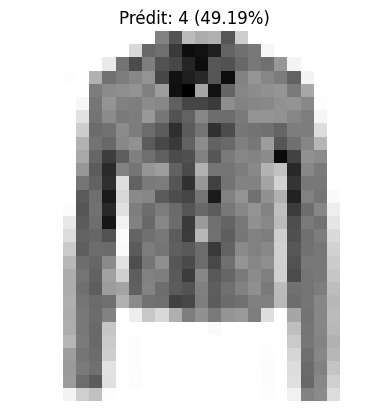

In [5]:
resultat = modele.evaluate(X_test, Y_test, verbose=0)
print('Valeur de l''erreur sur les données de test (loss):', resultat[0])
print('Précision sur les données de test (accuracy):', resultat[1])

import numpy as np
import matplotlib.pyplot as plt

# Prédiction du modèle
Y_predict = modele.predict(X_test)

# Exemple sur une image spécifique
i = 10

# Trouver l'indice de la classe prédite
classe_predite = np.argmax(Y_predict[i])

# Trouver la probabilité associée
probabilite_predite = Y_predict[i][classe_predite] * 100

# Afficher les résultats
print("Sortie réseau (vecteur de probabilités) :", Y_predict[i])
print("Classe attendue :", Y_test_data[i])  # Note: Y_test_data, not Y_test
print(f"Classe prédite : {classe_predite} avec une probabilité de {probabilite_predite:.2f}%")

# Afficher l'image
plt.imshow(X_test_data[i], cmap='Greys') #  X_test_data, not X_test
plt.title(f"Prédit: {classe_predite} ({probabilite_predite:.2f}%)")
plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


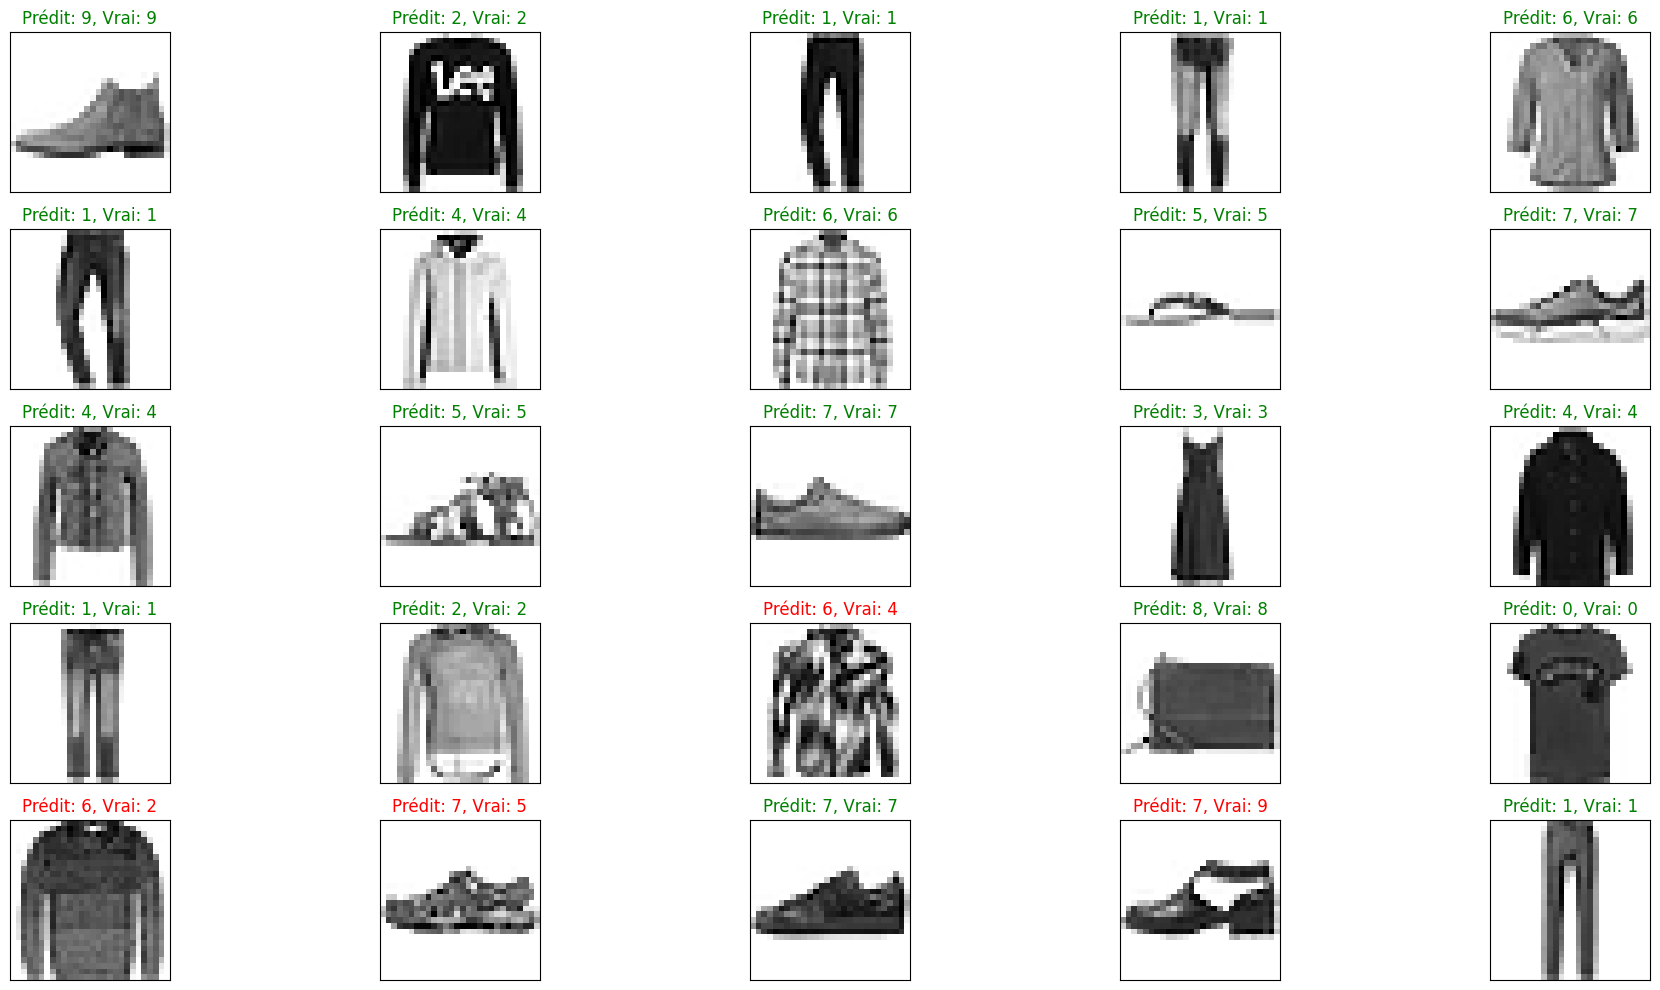

In [6]:
# C. Afficher Plusieurs Prédictions
Y_predict = modele.predict(X_test)
num_rows = 5
num_cols = 5
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(X_test_data[i], cmap=plt.cm.binary)
    classe_predite = np.argmax(Y_predict[i])
    classe_attendue = np.argmax(Y_test[i])  # Corrected: Use one-hot encoded Y_test for comparison
    if classe_predite == classe_attendue:
        color = "green"
    else:
        color = "red"
    plt.title(f"Prédit: {classe_predite}, Vrai: {classe_attendue}", color=color)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

Matrice de Confusion

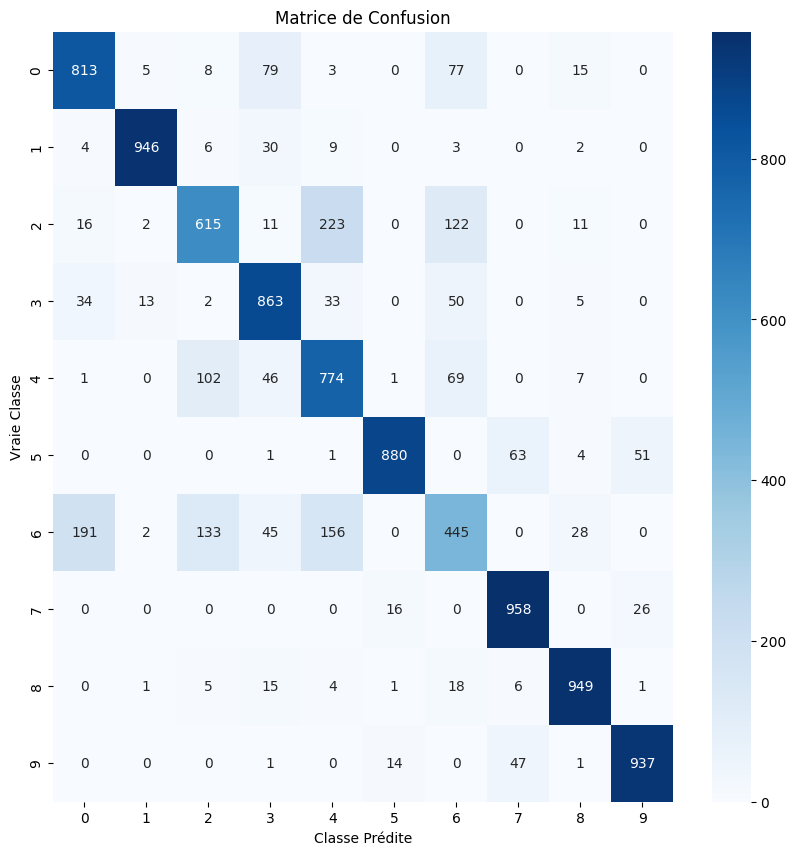

In [7]:
# D. Matrice de Confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_predict_classes = np.argmax(Y_predict, axis=1)  # Convertir les prédictions one-hot en classes
Y_true_classes = np.argmax(Y_test, axis=1)  # Convertir les vraies étiquettes one-hot en classes
conf_matrix = confusion_matrix(Y_true_classes, Y_predict_classes)

plt.figure(figsize=(10, 10))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.title('Matrice de Confusion')
plt.show()

Rapport de Classification

In [8]:
# E. Rapport de Classification
from sklearn.metrics import classification_report

Y_predict_classes = np.argmax(Y_predict, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

print(classification_report(Y_true_classes, Y_predict_classes))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79      1000
           1       0.98      0.95      0.96      1000
           2       0.71      0.61      0.66      1000
           3       0.79      0.86      0.83      1000
           4       0.64      0.77      0.70      1000
           5       0.96      0.88      0.92      1000
           6       0.57      0.45      0.50      1000
           7       0.89      0.96      0.92      1000
           8       0.93      0.95      0.94      1000
           9       0.92      0.94      0.93      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



In [ ]:
Afficher les probabilités de prédiction pour une image

In [9]:
# F. Afficher les probabilités de prédiction pour une image
i = 10
print("Probabilités pour l'image", i, ":", Y_predict[i])

Probabilités pour l'image 10 : [1.9310722e-03 5.4334127e-03 3.8824075e-01 1.8595256e-03 4.9188930e-01
 2.5885566e-03 1.0699884e-01 3.9605948e-07 1.0441209e-03 1.4086333e-05]
